# Updated Forensic Project

## Create a synthetic data set (No fraud injected)

In [2]:
# install the faker module
!pip install Faker

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 98.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


### Create a base data fram

In [3]:
# import the libaries
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import timedelta
import matplotlib.pyplot as plt

# Initialize Faker and assign seed number
faker = Faker()
faker.seed_instance(42)
np.random.seed(42)
random.seed(42)

# Add realistic expense descriptions using Faker
def generate_description():
    expense_items = [
        'diesel fuel',
        'office supplies',
        'marketing services',
        'consulting fees',
        'IT hardware',
        'repair and maintenance',
        'electricity bill',
        'legal advisory',
        'travel reimbursement',
        'stationery',
        'software license',
        'staff training',
        'warehouse rental'
    ]
    actions = [
        'Purchase of',
        'Payment for',
        'Reimbursement for',
        'Consulting for',
        'Service fee for',
        'Expense for',
        'Procurement of',
        'Invoice for'
    ]
    return f"{faker.random_element(actions)} {faker.random_element(expense_items)}"

# field values 
departments = ['Finance', 'HR', 'Engineering', 'Marketing', 'Sales']
payment_methods = ['Credit Card', 'Bank Transfer', 'Cash', 'Mobile Payment']
locations = ['New York', 'Bangkok', 'London', 'Singapore', 'Berlin']
approver = ['Angeline Jolie', 'Rober Pattison','Patrick Batemen','Bruce Wayne','Bradd Pitt']

# define department, approver hierarchy
hierarchy = {
    'Finance': {'approver': 'Bradd Pitt', 'employee_id': [1001, 1009,1011,1012]},
    'Marketing': {'approver': 'Angeline Jolie', 'employee_id': [1002, 1004]},
    'HR': {'approver': 'Rober Pattison', 'employee_id': [1003, 1006]},
    'Sales': {'approver': 'Patrick Batemen', 'employee_id': [1005, 1008]},
    'Engineering': {'approver': 'Bruce Wayne', 'employee_id': [1007, 1010]}
}

location_hierarchy ={
        'Telsa':'New York',
        'Google' : 'Bangkok',
        'Apple' :'London',
        'Meta':'Singapore',
        'OpenAI':'Berlin'
}

# Dataset size
n_transactions = 1100

# Base DataFrame with base columns
df = pd.DataFrame({
    'transaction_id': np.arange(1, n_transactions + 1),
    'transaction_date': pd.date_range(start='2025-01-01', periods=n_transactions, freq='H'),
    'employee_id': np.random.choice(range(1001, 1011), n_transactions),
    'vendor_name': np.random.choice(
        ['Telsa', 'Apple', 'Google', 'Meta','OpenAI'], n_transactions),
    'invoice_number': ['INV-' + str(random.randint(1000, 9999)) for _ in range(n_transactions)],
    'payment_methods' :np.random.choice(payment_methods,n_transactions),
    'amount': np.random.normal(loc=1000, scale=20, size=n_transactions).round(2),
    'fraud': 0,
    'fraud_type': None
})


# map the depart and approver based on employee id
employee_to_dept = {}
employee_to_approver = {}

for dept, info in hierarchy.items():
    for emp in info['employee_id']:
        employee_to_dept[emp] = dept
        employee_to_approver[emp] = info['approver']

# Add consistent department and approver columns
df['department'] = df['employee_id'].map(employee_to_dept)
df['approver'] = df['employee_id'].map(employee_to_approver)

# Map the location to the vendor
df['location'] = df['vendor_name'].map(location_hierarchy)

# update to make less than 3 employees interacting with vendor
for vendor in df['vendor_name'].unique():
    emp_pool = df[df['vendor_name'] == vendor]['employee_id'].unique()
    if len(emp_pool) > 2:
        keep_employees = np.random.choice(emp_pool, 2, replace=False)
        df.loc[(df['vendor_name'] == vendor) & (~df['employee_id'].isin(keep_employees)), 'employee_id'] = np.random.choice(keep_employees)

# update the transaction_date to have transactions recorded in business hours only
# ##Create business days 
days_needed = (n_transactions // 13) + 10

# # ##Create a list of hourly timestamps from 9 AM to 9 PM each day
business_hours = []
for date in pd.date_range(start='2025-01-01', periods=days_needed, freq='D'):
    # print(date)
    for hour in range(9, 22): 
        business_hours.append(pd.Timestamp(date.year, date.month, date.day, hour))

# ##Randomly pick n_transactions timestamps from business_hours
transaction_dates = np.random.choice(business_hours, size=n_transactions, replace=True)

# ## Shuffle 
np.random.shuffle(transaction_dates)

# ##Assign back to the dataframe
df['transaction_date'] = transaction_dates


# add description
df['description'] = [generate_description() for _ in range(len(df))]

print(f'Before injecting fraud : {len(df)}')



# ## ----------------- INJECTING FRAUD ---------------- ###

# ## Duplicate invoices
duplicate_invoice_indices = []

for i in range(3):
    original = df.sample(1).iloc[0]
    for delay_hours in [1, 3]:  # Two slightly delayed duplicates
        fraud = original.copy()
        
        # Adjust unique fields to make it look slightly different
        fraud['transaction_id'] = df['transaction_id'].max() + 1 # duplicate trans_id is random 
        fraud['transaction_date'] += timedelta(hours=delay_hours)
        
        # Fraud labeling
        fraud['fraud'] = 1
        fraud['fraud_type'] = 'Duplicate Invoice'
        
        # Append to DataFrame and track the new index
        df.loc[len(df)] = fraud
        duplicate_invoice_indices.append(len(df) - 1)

print("Duplicate Invoice frauds added at indices:", duplicate_invoice_indices)

# return the affected rows
df[df.index.isin(duplicate_invoice_indices)]

# ## Suspicious round amount
round_amounts = [900, 950, 1000, 1050]
round_amt_indices = []

for i in range(4):
    idx = random.randint(0, n_transactions-1)
    df.loc[idx, 'amount'] = np.random.choice(round_amounts)
    df.loc[idx, 'fraud'] = 1
    df.loc[idx, 'fraud_type'] = 'Round suspicious amount'
    round_amt_indices.append(idx)

print('Round suspicious amount:',round_amt_indices )

# return the affected rows
df[df.index.isin(round_amt_indices)]


# ## Amount just below threshold

threshold_amounts = [1062.00,1063.00]
amt_below_threshold_indices= []

for i in range(2):
    idx = np.random.choice(df.index)
    df.loc[idx, 'amount'] = np.random.choice(threshold_amounts)
    df.loc[idx, 'fraud'] = 1
    df.loc[idx, 'fraud_type'] = 'Amount just below threshold'
    amt_below_threshold_indices.append(idx)

print('Amount just below threshold:',amt_below_threshold_indices)

df[df.index.isin(amt_below_threshold_indices)]

# ##Same vendor used by multiple employees
target_vendor = 'Google'
employees = [1001, 1002, 1011,1012]
vendor_multiple_indices = []

for emp in employees:
    idx = np.random.choice(df[df['employee_id'] != emp].index)
    df.loc[idx, 'employee_id'] = emp
    df.loc[idx, 'vendor_name'] = target_vendor
    df.loc[idx, 'fraud'] = 1
    df.loc[idx, 'fraud_type'] = 'Same vendor used by multiple employees'
    vendor_multiple_indices.append(idx)

print('Same vendor used by multiple employees:',vendor_multiple_indices)

df[df.index.isin(vendor_multiple_indices)]


# ##Suspicious keywords in description

suspicious_keywords = ['gift', 'cash', 'urgent']
key_words_indices = []

for _ in range(3):
    idx = np.random.choice(df.index)
    keyword = np.random.choice(suspicious_keywords)
    df.loc[idx, 'description'] = f"Payment for {keyword} expense"
    df.loc[idx, 'fraud'] = 1
    df.loc[idx, 'fraud_type'] = 'Suspicious keyword in description'
    key_words_indices.append(idx)

print('Suspicious keywords in description:',key_words_indices)

df[df.index.isin(key_words_indices)]

# ##Vendor with high amount

target_vendor_high = 'Telsa'
avg_vendor_amt = df[df['vendor_name'] == target_vendor_high]['amount'].mean()
high_amount = round(avg_vendor_amt * 2.5, 2)
high_amt_vendor_indices = []

for _ in range(2):
    idx = np.random.choice(df[df['vendor_name'] != target_vendor_high].index)
    df.loc[idx, 'vendor_name'] = target_vendor_high
    df.loc[idx, 'amount'] = high_amount
    df.loc[idx, 'fraud'] = 1
    df.loc[idx, 'fraud_type'] = 'Vendor with high amount'
    high_amt_vendor_indices.append(idx)

print('Vendor with high amount:',high_amt_vendor_indices)

df[df.index.isin(high_amt_vendor_indices)]

# ## Approver not in the list
fraud_entry = {
    'transaction_id': 1107,
    'transaction_date': pd.Timestamp('2025-02-01 10:00'),
    'department': 'Finance',
    'employee_id': 1009,
    'vendor_name': 'Apple',
    'location': 'London',
    'approver': 'Ryan Reynolds',
    'invoice_number': 'INV-8888',
    'payment_methods': 'Bank Transfer',
    'amount': 1008.35,
    'description': 'Invoice for Apple product purchase',
    'fraud': 1,
    'fraud_type': 'Approver not in list'
}

print('Approver not in the list:',1106)

# ## Laid off employee 
laid_off_id = 1003
laid_off_date = '2025-04-04T20:00:00.000'

fraud_entry_1 =  {
    'transaction_id':1108,
    'transaction_date': pd.Timestamp('2025-04-05T10:00:00.000'),
    'department': 'HR',
    'employee_id': 1003,
    'vendor_name': 'Meta',
    'location': 'Singapore',
    'approver': 'Rober Pattison',
    'invoice_number': 'INV-3065',
    'payment_methods': 'Mobile Payment',
    'amount': 908.58,
    'description': 'Expense for software license',
    'fraud': 1,
    'fraud_type': 'Laid off employee'
}
print('Laid off employee :',1107)

# ## Late night transactions
fraud_entry_2 =  {
    'transaction_id':1111,
    'transaction_date': pd.Timestamp('2025-02-13 23:00'),
    'department': 'Sales',
    'employee_id': 1005,
    'vendor_name': 'Meta',
    'location': 'Singapore',
    'approver': 'Patrick Batemen',
    'invoice_number': 'INV-4999',
    'payment_methods': 'Bank Transfer',
    'amount': 875.23,
    'description': 'Payment for the CEO Wang fees',
    'fraud': 1,
    'fraud_type': 'Late night transaction'
}
print('Late night transactions :',1108)


# add to the data frame
df = pd.concat([df,pd.DataFrame([fraud_entry,fraud_entry_1,fraud_entry_2])],ignore_index=True)

# update on the location
# Map the location to the vendor
df['location'] = df['vendor_name'].map(location_hierarchy)

# replace null with genuine for null values in fraud type
df.loc[(df['fraud'] == 0) & (df['fraud_type'].isna()), 'fraud_type'] = 'genuine'


# reshuffled the transaction_id to introduce randomnesss
df['transaction_id'] = np.random.permutation(df['transaction_id'].values)

print(f'After injecting fraud : {len(df)}')





Before injecting fraud : 1100
Duplicate Invoice frauds added at indices: [1100, 1101, 1102, 1103, 1104, 1105]
Round suspicious amount: [477, 672, 302, 5]
Amount just below threshold: [1045, 988]
Same vendor used by multiple employees: [562, 675, 1071, 694]
Suspicious keywords in description: [586, 106, 897]
Vendor with high amount: [1043, 946]
Approver not in the list: 1106
Laid off employee : 1107
Late night transactions : 1108
After injecting fraud : 1109


In [3]:
# df.groupby('vendor_name')['employee_id'].unique()

# df[df['employee_id'] == 1003]['transaction_date'].sort_values()

pd.Timestamp('2025-04-05T10:00:00.000')

Timestamp('2025-04-05 10:00:00')

In [4]:
df['fraud_type'].value_counts()

fraud_type
genuine                                   1085
Duplicate Invoice                            6
Round suspicious amount                      4
Same vendor used by multiple employees       4
Suspicious keyword in description            3
Vendor with high amount                      2
Amount just below threshold                  2
Approver not in list                         1
Laid off employee                            1
Late night transaction                       1
Name: count, dtype: int64

In [5]:
df['amount'].describe()

count    1109.000000
mean     1002.710027
std        67.158802
min       875.230000
25%       987.000000
50%       999.810000
75%      1013.120000
max      2506.870000
Name: amount, dtype: float64

In [4]:
# copy the data frame
df_rule_pass = df.copy()


## Create function to flag and assign the risk score

In [7]:
approver_list = [i['approver'] for i in hierarchy.values()]
vendor_list = [i for i in df['vendor_name'].unique()]

# ## Laid off employee 
laid_off_id = 1003
laid_off_date = pd.Timestamp('2025-04-04T20:00:00.000')

def apply_rule_based_flags(df):
    flags_list = []
    risk_levels = []
    frauds = []

    # Initialize rule counts
    rule_counts = {
        "Duplicate Invoice": 0,
        "Round Suspicious Amount": 0,
        "Amount Just Below Threshold": 0,
        "Suspicious Keyword in Description": 0,
        "Vendor Used By > 4 Employees": 0,
        "Vendor High Amount": 0,
        "Invalid approver": 0,
        "Invalid employee": 0,
        "Late night transactions": 0
    }

    for i, row in df.iterrows():
        flags = []

        if not df[(df['vendor_name'] == row['vendor_name']) & 
                  (df['invoice_number'] == row['invoice_number']) & 
                  (df['amount'] == row['amount']) & 
                  (df['employee_id'] == row['employee_id']) & 
                  (df.index != row.name)].empty:
            flags.append("Duplicate Invoice")
            rule_counts["Duplicate Invoice"] += 1

        if row['amount'] % 50 == 0:
            flags.append("Round Suspicious Amount")
            rule_counts["Round Suspicious Amount"] += 1

        if 1062 <= row['amount'] <= 1063:
            flags.append("Amount Just Below Threshold")
            rule_counts["Amount Just Below Threshold"] += 1

        keywords = ['gift', 'cash', 'urgent']
        if isinstance(row['description'], str) and any(word in row['description'].lower() for word in keywords):
            flags.append("Suspicious Keyword in Description")
            rule_counts["Suspicious Keyword in Description"] += 1

        vendor_employee_count = df.groupby('vendor_name')['employee_id'].nunique()
        if vendor_employee_count[row['vendor_name']] > 4:
            flags.append("Vendor Used By > 4 Employees")
            rule_counts["Vendor Used By > 4 Employees"] += 1
            
        avg_amount = df[df['vendor_name'] == row['vendor_name']]['amount'].mean()
        if row['amount'] > 2 * avg_amount:
            flags.append("Vendor High Amount")
            rule_counts["Vendor High Amount"] += 1

        if row['approver'] not in approver_list:
            flags.append('Invalid approver')
            rule_counts["Invalid approver"] += 1

        if row['transaction_date'].hour >= 23 or row['transaction_date'].hour < 2:
            flags.append('Late night transactions')
            rule_counts["Late night transactions"] += 1

        if (row['employee_id'] == laid_off_id) and (row['transaction_date'] > laid_off_date):
            flags.append('Transaction logged by invalid employee') 
            rule_counts["Invalid employee"] += 1

        num_flags = len(flags)

        if num_flags == 0:
            frauds.append(0)
            risk_levels.append('Low')
        elif num_flags == 1:
            frauds.append(1)
            risk_levels.append('Medium')
        elif num_flags == 2:
            frauds.append(1)
            risk_levels.append('High')
        else:
            frauds.append(1)
            risk_levels.append('Critical')

        flags_list.append(flags)

    df['flags1'] = flags_list
    df['risk_level'] = risk_levels
    df['fraud1'] = frauds

    print("Rule counts:")
    for rule, count in rule_counts.items():
        print(f"{rule}: {count}")

    return df

# apply the function on the copied data
df_checked = apply_rule_based_flags(df_rule_pass)

# extract the flagged records by rules
x = df_checked[df_checked['fraud1'] == 1]

# number of flagged transactions
len(df_checked[df_checked['fraud1'] == 1])

Rule counts:
Duplicate Invoice: 9
Round Suspicious Amount: 5
Amount Just Below Threshold: 4
Suspicious Keyword in Description: 3
Vendor Used By > 4 Employees: 211
Vendor High Amount: 2
Invalid approver: 1
Invalid employee: 1
Late night transactions: 2


228

In [8]:
# df_checked[df['fraud']==1].sort_values(by='transaction_date')
x[x['fraud1']==1].sort_values(by='transaction_date')

,transaction_id,transaction_date,employee_id,vendor_name,invoice_number,payment_methods,amount,fraud,fraud_type,department,approver,location,description,flags1,risk_level,fraud1
442,13,2025-01-01 09:00:00,1001,Google,INV-5649,Mobile Payment,991.27,0,genuine,Finance,Bradd Pitt,Bangkok,Consulting for software license,[Vendor Used By > 4 Employees],Medium,1
5,300,2025-01-01 13:00:00,1005,Meta,INV-3286,Bank Transfer,1050.00,1,Round suspicious amount,Engineering,Bruce Wayne,Singapore,Procurement of diesel fuel,[Round Suspicious Amount],Medium,1
584,455,2025-01-01 14:00:00,1003,Google,INV-5198,Cash,964.48,0,genuine,Sales,Patrick Batemen,Bangkok,Procurement of marketing services,[Vendor Used By > 4 Employees],Medium,1
962,391,2025-01-01 16:00:00,1003,Google,INV-5183,Credit Card,993.30,0,genuine,Sales,Patrick Batemen,Bangkok,Reimbursement for staff training,[Vendor Used By > 4 Employees],Medium,1
625,775,2025-01-01 17:00:00,1003,Google,INV-5397,Mobile Payment,1001.39,0,genuine,Sales,Patrick Batemen,Bangkok,Payment for software license,[Vendor Used By > 4 Employees],Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,153,2025-04-04 13:00:00,1003,Google,INV-2084,Credit Card,1018.38,0,genuine,Finance,Bradd Pitt,Bangkok,Payment for software license,[Vendor Used By > 4 Employees],Medium,1
950,677,2025-04-04 17:00:00,1003,Google,INV-3950,Bank Transfer,1039.25,0,genuine,Engineering,Bruce Wayne,Bangkok,Expense for software license,[Vendor Used By > 4 Employees],Medium,1
493,822,2025-04-04 19:00:00,1003,Google,INV-5499,Cash,1006.39,0,genuine,Engineering,Bruce Wayne,Bangkok,Consulting for office supplies,[Vendor Used By > 4 Employees],Medium,1
570,790,2025-04-04 20:00:00,1003,Google,INV-4673,Credit Card,956.93,0,genuine,Marketing,Angeline Jolie,Bangkok,Purchase of stationery,[Vendor Used By > 4 Employees],Medium,1


### reason for high false positive (Genuine flagged as fraud)
- There were alot of late night transaction which is result of data generating inefficiencies (In real world, data recorded late at night would be significantly lower than proprtion being flagged in our rule-flagging)
- Vendonr used by more than 3 employees flagged all of the transactions in our data set this is also due to data genrating inefficiencies where all of employees interacted with all the vendors 

In [9]:
# risk summary
risk_summary = df_checked[df_checked['fraud1'] == 1]['risk_level'].value_counts()
display(risk_summary)


risk_level
Medium      219
High          8
Critical      1
Name: count, dtype: int64

In [10]:
merg_df = pd.merge(x,df[df['fraud']==1],on='transaction_id',how='left')

# merg_df

In [11]:
df.info()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1109 non-null   int64         
 1   transaction_date  1109 non-null   datetime64[ns]
 2   employee_id       1109 non-null   int64         
 3   vendor_name       1109 non-null   object        
 4   invoice_number    1109 non-null   object        
 5   payment_methods   1109 non-null   object        
 6   amount            1109 non-null   float64       
 7   fraud             1109 non-null   int64         
 8   fraud_type        1109 non-null   object        
 9   department        1109 non-null   object        
 10  approver          1109 non-null   object        
 11  location          1109 non-null   object        
 12  description       1109 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(8)
memory usage: 112.8+ KB


Index(['transaction_id', 'transaction_date', 'employee_id', 'vendor_name',
       'invoice_number', 'payment_methods', 'amount', 'fraud', 'fraud_type',
       'department', 'approver', 'location', 'description'],
      dtype='object')

## Run ML model

In [6]:
# import relevant features
import datetime
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score,RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# copy the data frame
df_1 = df.copy()

## strip the INV- letter from the invoice_number column and cast as interger
df_1['invoice_number'] = df_1['invoice_number'].str.extract(r'(\d+)')
df_1['invoice_number'] = df_1['invoice_number'].astype(int)

# extract date,month,year from the transaction_date and drop the transactio_date
df_1['transaction_date'] = pd.to_datetime(df_1['transaction_date'])

# df_1['year'] = df_1['transaction_date'].dt.year # remove year as there is only a year 2025 data; may act as noise
df_1['month'] = df_1['transaction_date'].dt.month
df_1['day'] = df_1['transaction_date'].dt.day
df_1['hour'] =  df_1['transaction_date'].dt.hour

df_1.drop('transaction_date', axis=1, inplace=True)

# split features by type
num_features = ['employee_id', 'invoice_number', 'amount', 'month', 'day', 'hour']
cat_features = ['vendor_name', 'payment_methods', 'department', 'approver', 'location', 'description']

# Features and target for train data
X = df_1[num_features + cat_features]
y = df_1['fraud']

# Preprocessing pipeline
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean'))])

cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipeline, num_features), ('cat', cat_pipeline, cat_features)])

# Apply preprocessing to training data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3, shuffle=True)

# Apply SMOTE ONLY on training data (to avoid data leakage)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

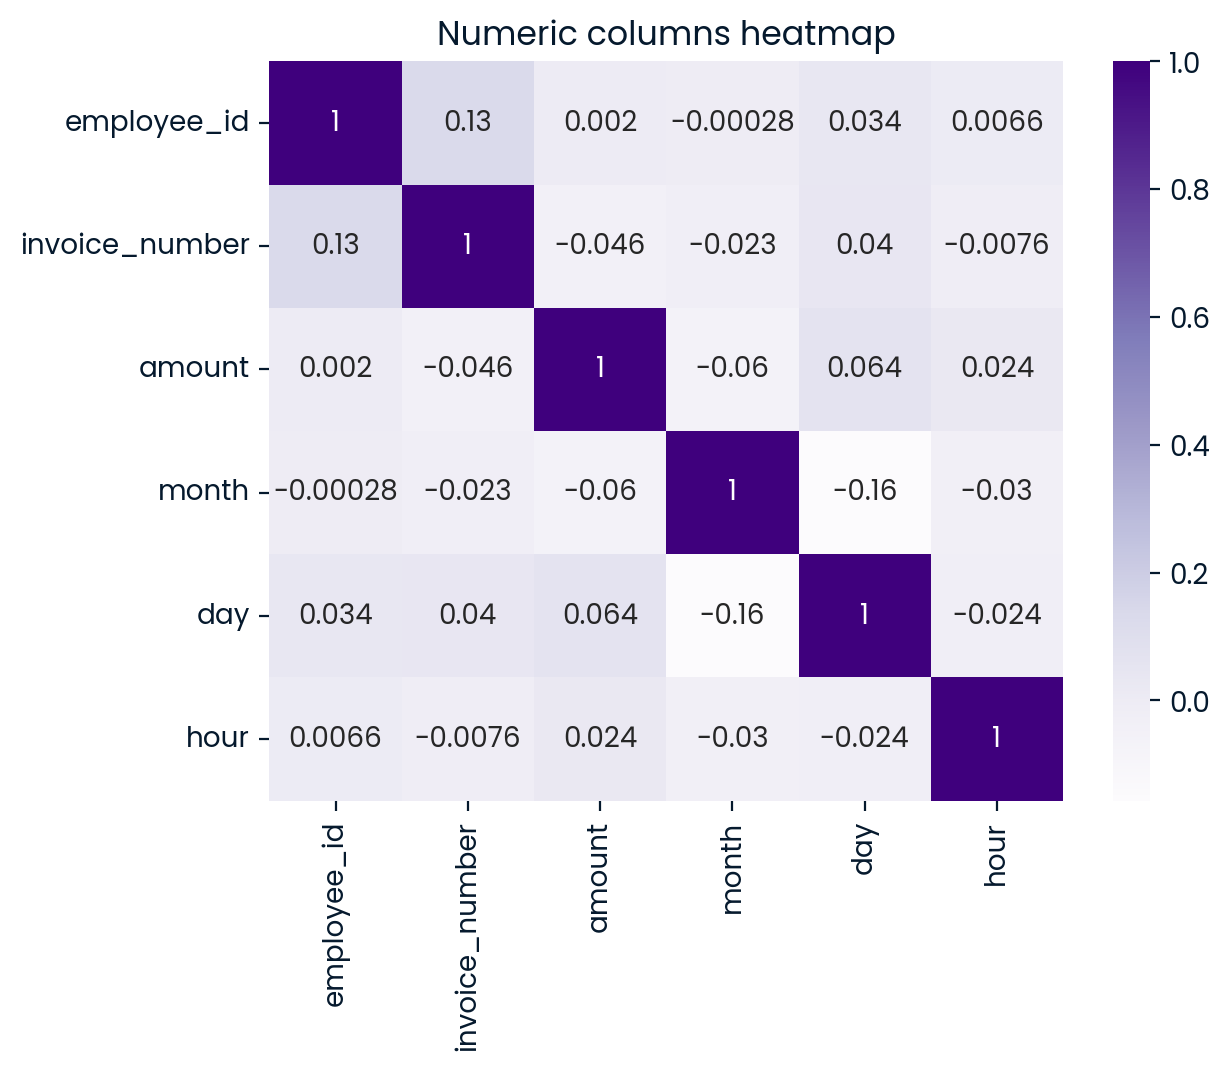

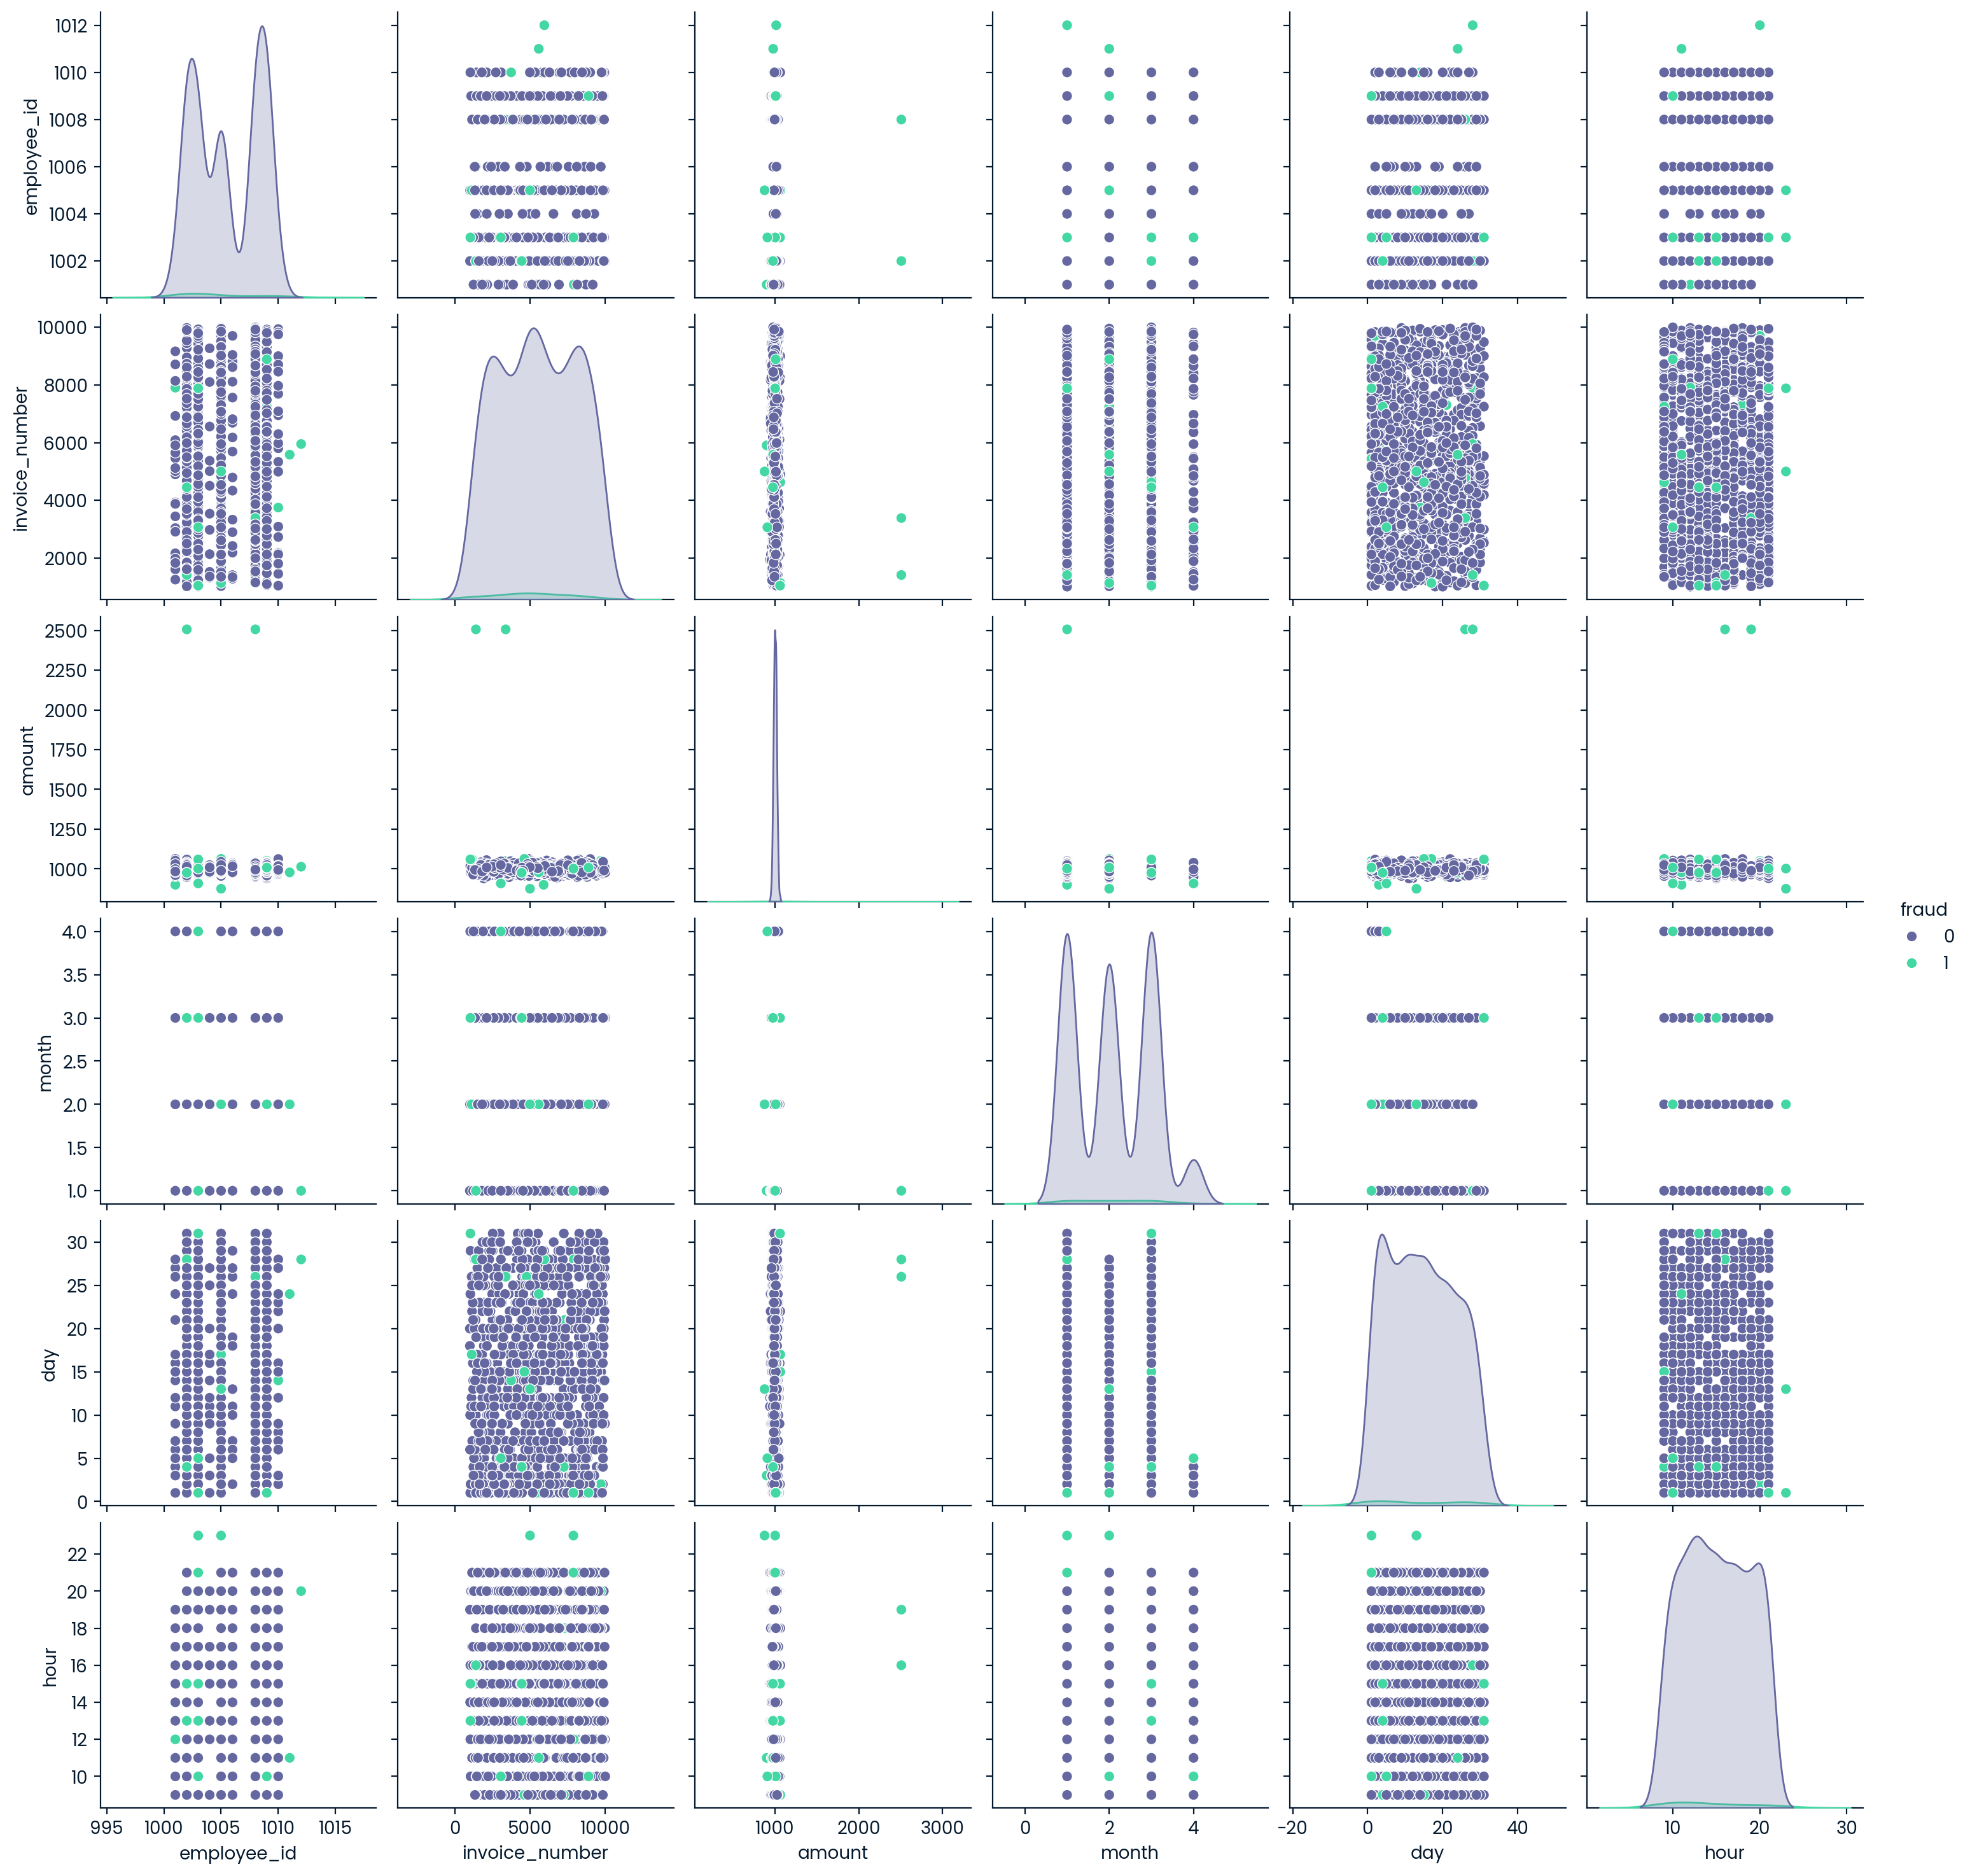

In [13]:
# import liabries
import seaborn as sns
import matplotlib.pyplot as plt

# plot heat map
sns.heatmap(df_1[num_features].corr(), cmap='Purples', annot=True)
plt.title('Numeric columns heatmap')
plt.show()

# plot pair plot
sns.pairplot(df_1, vars=num_features, hue='fraud')
plt.show()



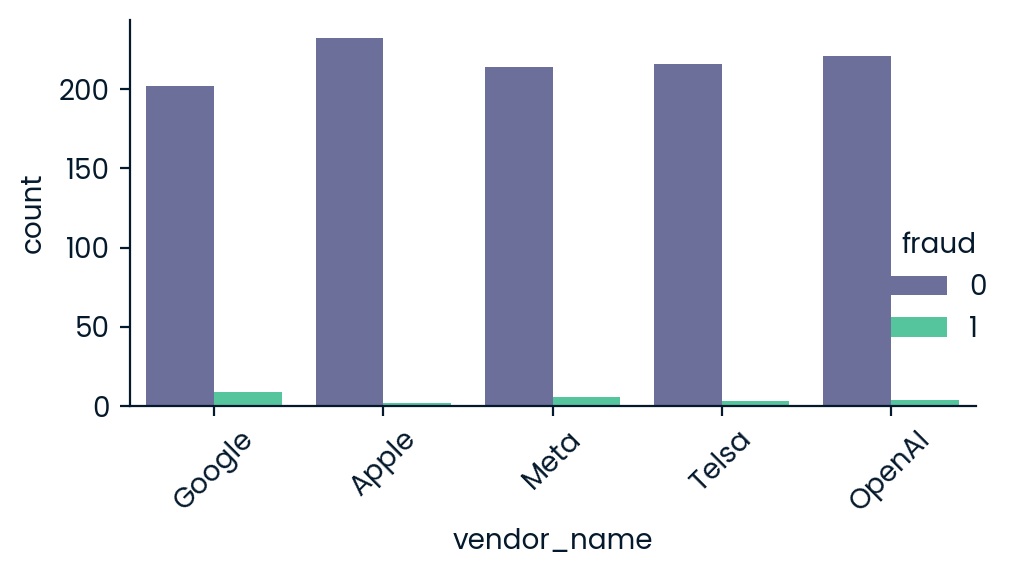

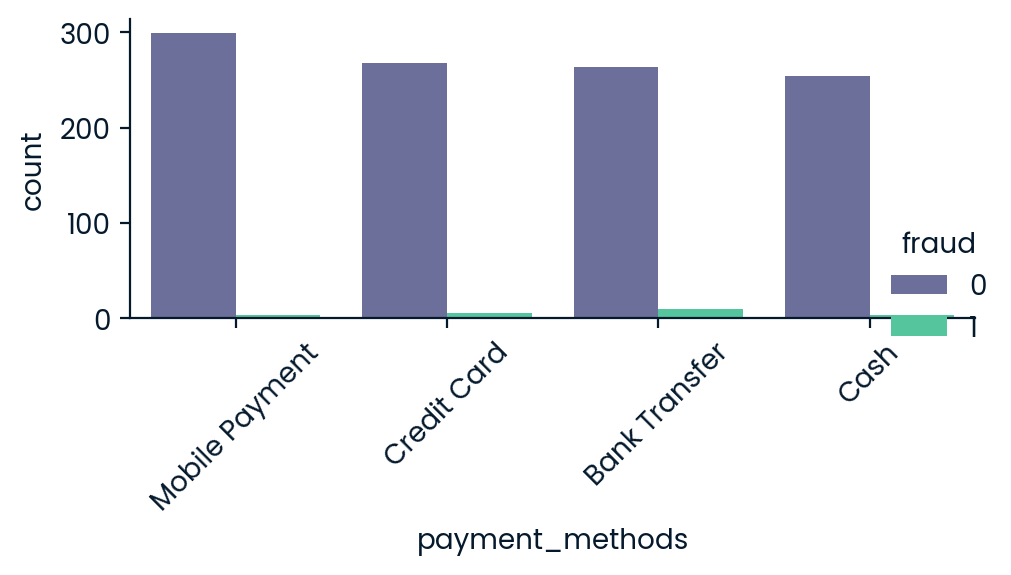

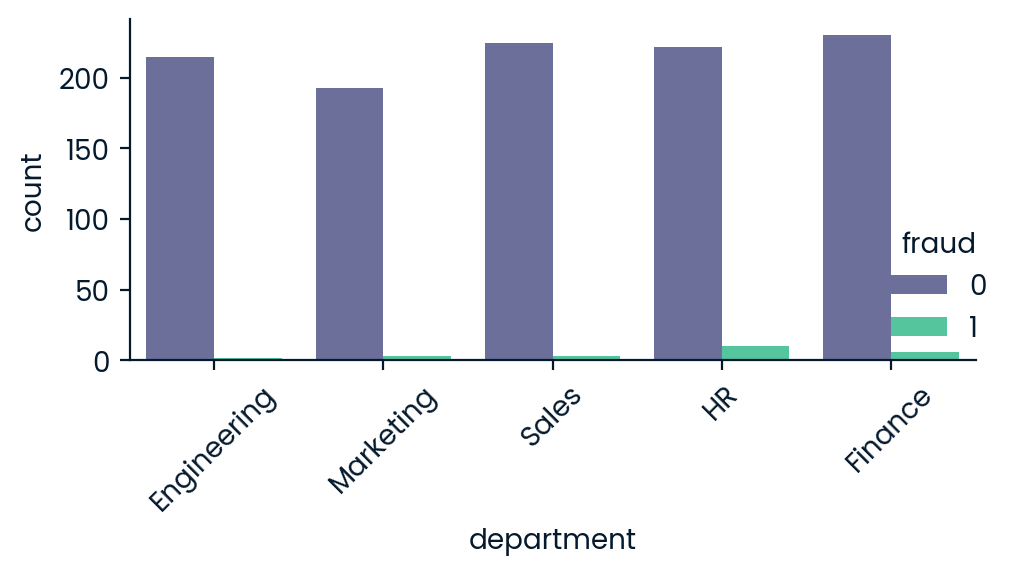

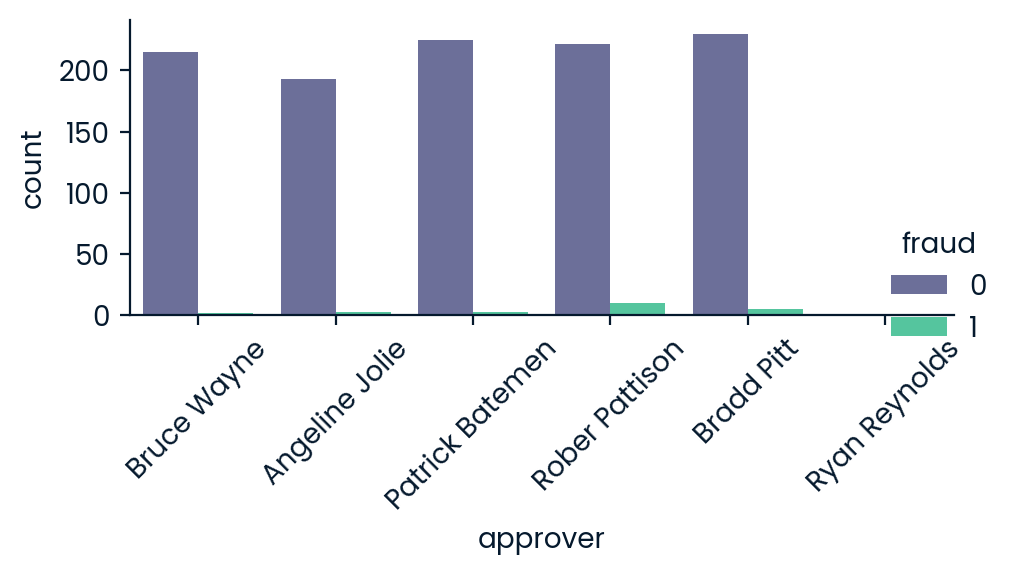

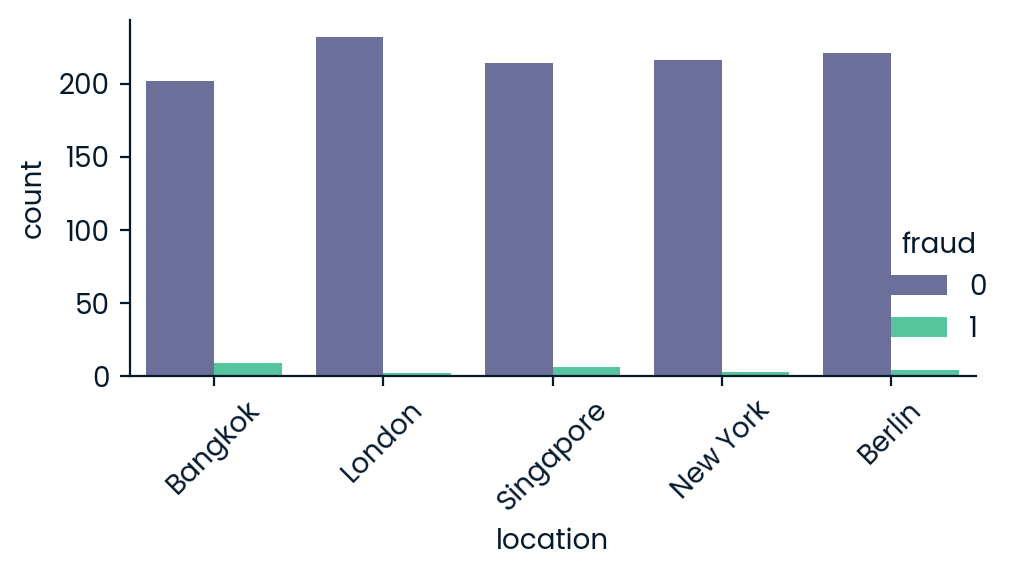

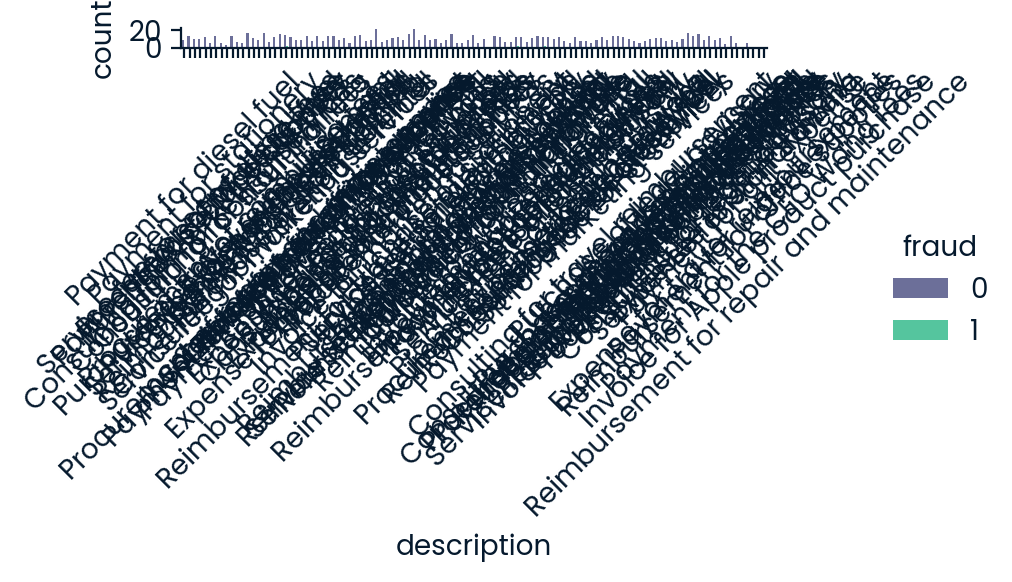

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_features:
    sns.catplot(data=df_1, x=col, hue='fraud', kind='count', height=3, aspect=1.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Logistic regression
Model is only working in predicting the majority class which is genuine and failing to predict fraud which is our objective of making model predict it.

Thus, model is simple not enough to meet our objective.

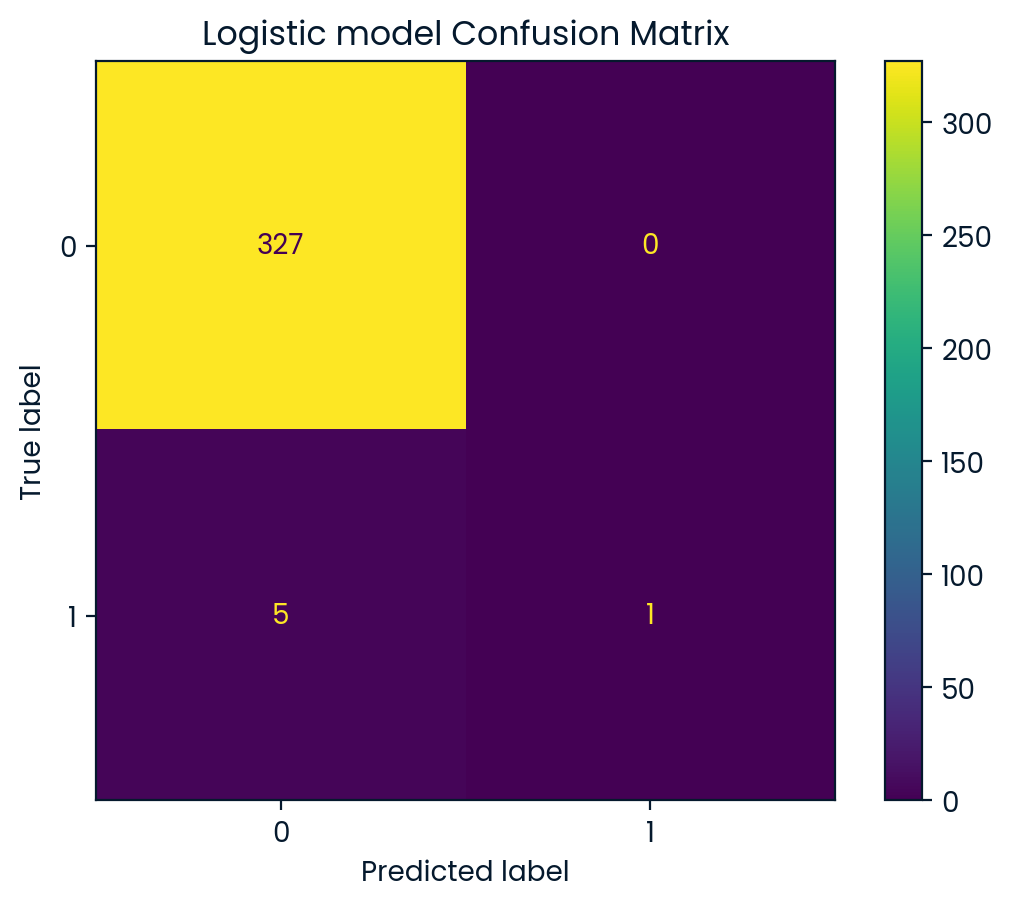

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       327
           1       1.00      0.17      0.29         6

    accuracy                           0.98       333
   macro avg       0.99      0.58      0.64       333
weighted avg       0.99      0.98      0.98       333

0.9780927835051546
0.984984984984985
CV train accuracy mean:0.9768072787427625


In [8]:
# connect pipe to model
lrg_model = Pipeline([('pipe',preprocessor),('lrg',LogisticRegression(random_state=42))])

# instanteiate model
lrg_model.fit(X_train,y_train)

# predict
lrg_y_pred = lrg_model.predict(X_test)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,lrg_y_pred)
plt.title('Logistic model Confusion Matrix')
plt.show()

# classification report
# classification report
print(classification_report(y_test,lrg_y_pred))

print(lrg_model.score(X_train,y_train))
print(lrg_model.score(X_test,y_test))

# evaluate the cross validated performance on training data
cv_scores = cross_val_score(lrg_model, X_train,y_train,cv=5, scoring='accuracy')

# print the results
print(f'CV train accuracy mean:{np.mean(cv_scores)}')

## Decisoin Tree Classifier

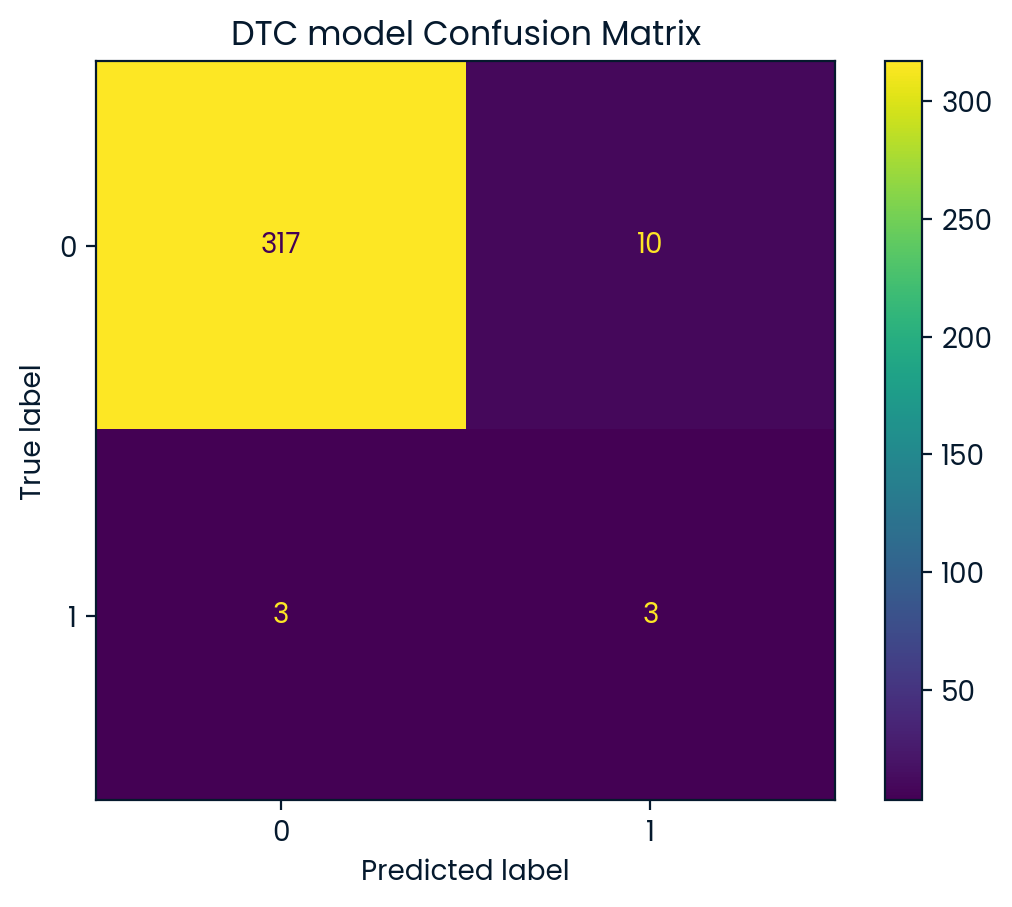

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       327
           1       0.23      0.50      0.32         6

    accuracy                           0.96       333
   macro avg       0.61      0.73      0.65       333
weighted avg       0.98      0.96      0.97       333

Training score of DTC is : 1.0
Testing score of DTC is : 0.960960960960961
CV train accuracy mean:0.9808754559666493 ,std dev:0.0063799339713648566 


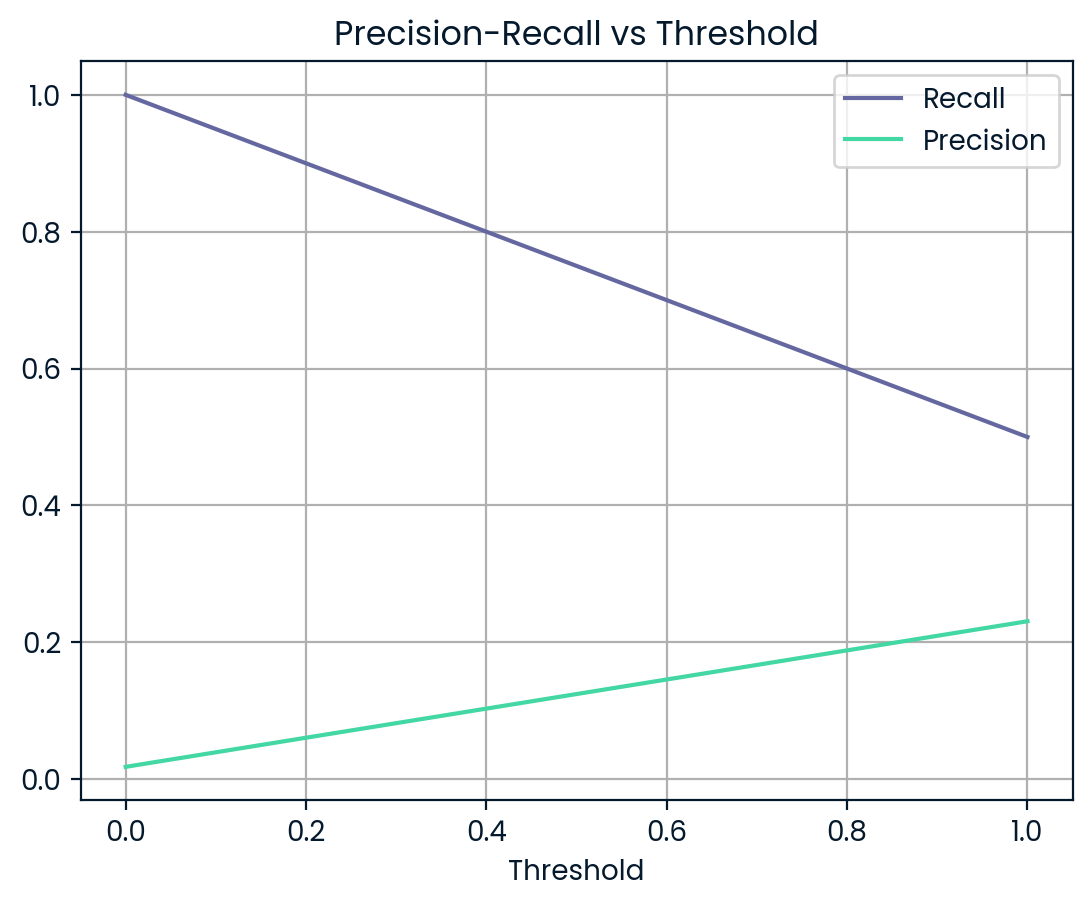

              precision    recall  f1-score   support

           0     0.9906    0.9694    0.9799       327
           1     0.2308    0.5000    0.3158         6

    accuracy                         0.9610       333
   macro avg     0.6107    0.7347    0.6478       333
weighted avg     0.9769    0.9610    0.9679       333



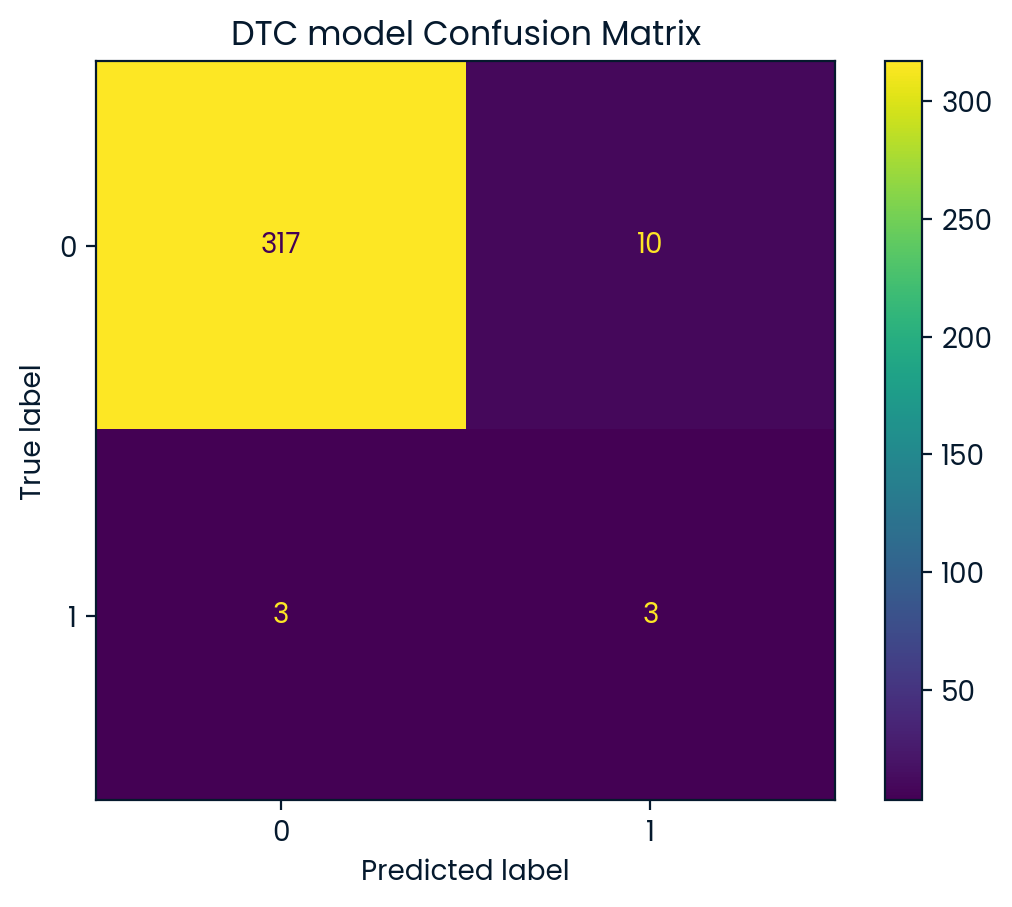

In [25]:
# connect the pipe to model
dtc_model= DecisionTreeClassifier(random_state=42,class_weight='balanced')

# instantiate model
dtc_model.fit(X_train_resampled,y_train_resampled)

# predict
dtc_y_pred = dtc_model.predict(X_test_preprocessed)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,dtc_y_pred)
plt.title('DTC model Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test,dtc_y_pred))

print(f'Training score of DTC is : {dtc_model.score(X_train_resampled,y_train_resampled)}')
print(f'Testing score of DTC is : {dtc_model.score(X_test_preprocessed,y_test)}')

# evaluate the cross validated performance on training data
cv_scores = cross_val_score(dtc_model, X_train_resampled,y_train_resampled,cv=5, scoring='accuracy')

# print the results
print(f'CV train accuracy mean:{np.mean(cv_scores)} ,std dev:{np.std(cv_scores)} ')


from sklearn.metrics import precision_recall_curve

y_probs = dtc_model.predict_proba(X_test_preprocessed)[:, 1]  # Prob for class 1 (fraud)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Plot
import matplotlib.pyplot as plt
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.xlabel('Threshold')
plt.legend()
plt.grid()
plt.title('Precision-Recall vs Threshold')
plt.show()

# Choose a lower threshold
y_pred_thresh = (y_probs >= 0.1).astype(int)
print(classification_report(y_test, y_pred_thresh, digits=4))

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_thresh)
plt.title('DTC model Confusion Matrix')
plt.show()

### False Negative 

In [17]:
# Get False Negatives: actual fraud (1) but predicted as legit (0)
false_negatives = X_test[(y_test == 1) & (dtc_y_pred == 0)]

# Add the true label for inspection
false_negatives['actual_label'] = y_test[(y_test == 1) & (dtc_y_pred == 0)]

# Now analyze these rows
false_negatives.head()

,employee_id,invoice_number,amount,month,day,hour,vendor_name,payment_methods,department,approver,location,description,actual_label
1102,1002,4450,975.59,3,4,13,OpenAI,Bank Transfer,Marketing,Angeline Jolie,Berlin,Procurement of legal advisory,1
477,1009,9702,1050.00,3,2,20,Meta,Cash,Finance,Bradd Pitt,Singapore,Purchase of software license,1
106,1002,7304,1019.30,1,21,18,OpenAI,Cash,HR,Rober Pattison,Berlin,Payment for cash expense,1


In [18]:
# Get True positive: actual fraud (1) but predicted as fraud (1)
tp = X_test[(y_test == 1) & (dtc_y_pred == 1)]

# Add the true label for inspection
tp['actual_label'] = y_test[(y_test == 1) & (dtc_y_pred == 1)]

# Now analyze these rows
tp.head()

,employee_id,invoice_number,amount,month,day,hour,vendor_name,payment_methods,department,approver,location,description,actual_label
694,1012,5952,1013.67,1,28,20,Google,Credit Card,Finance,Bradd Pitt,Bangkok,Consulting for marketing services,1
988,1005,1132,1063.00,2,17,15,Meta,Mobile Payment,Marketing,Angeline Jolie,Singapore,Reimbursement for warehouse rental,1
1043,1002,1410,2506.87,1,28,16,Telsa,Credit Card,Finance,Bradd Pitt,New York,Invoice for IT hardware,1


Fitting 5 folds for each of 96 candidates, totalling 480 fits


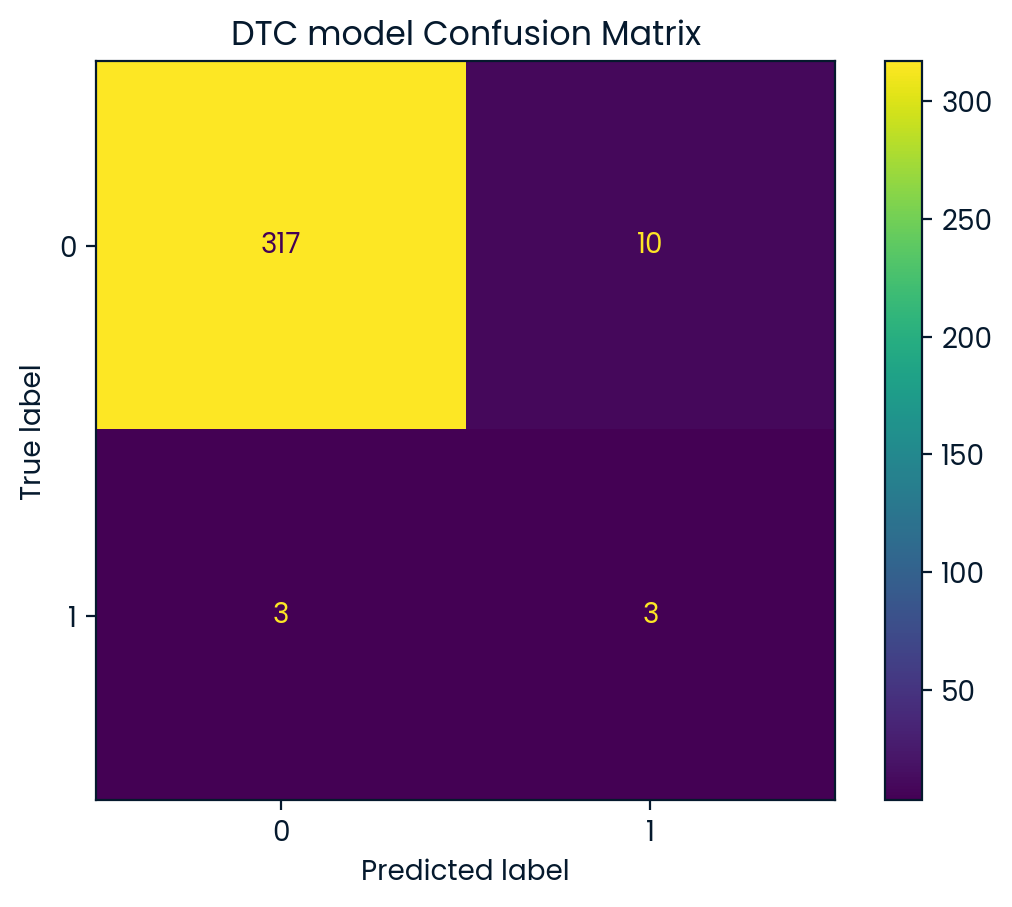

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       327
           1       0.23      0.50      0.32         6

    accuracy                           0.96       333
   macro avg       0.61      0.73      0.65       333
weighted avg       0.98      0.96      0.97       333

1.0
0.5
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
CV train accuracy mean:0.9861559840194545 ,std dev:0.007612331810151255 


In [19]:
# set the parameters
param_grid = {
    'max_depth': [3, 5,7, None],
    'min_samples_split': [2, 3,5,10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'] 
}
# grid search for optimal parameter
dtc_model_tune = GridSearchCV(estimator=dtc_model, param_grid=param_grid, cv=5, scoring='recall', verbose=1, n_jobs=-1)

# instantiate model
dtc_model_tune.fit(X_train_resampled,y_train_resampled)

# predict
dtc_tune_y_pred = dtc_model_tune.predict(X_test_preprocessed)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,dtc_tune_y_pred)
plt.title('DTC model Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test,dtc_tune_y_pred))

print(dtc_model_tune.score(X_train_resampled,y_train_resampled))
print(dtc_model_tune.score(X_test_preprocessed,y_test))

# evaluate the cross validated performance on training data
cv_scores = cross_val_score(dtc_model_tune, X_train_resampled,y_train_resampled,cv=5, scoring='accuracy')

# print the results
print(f'CV train accuracy mean:{np.mean(cv_scores)} ,std dev:{np.std(cv_scores)} ')

## Random Tree Forest

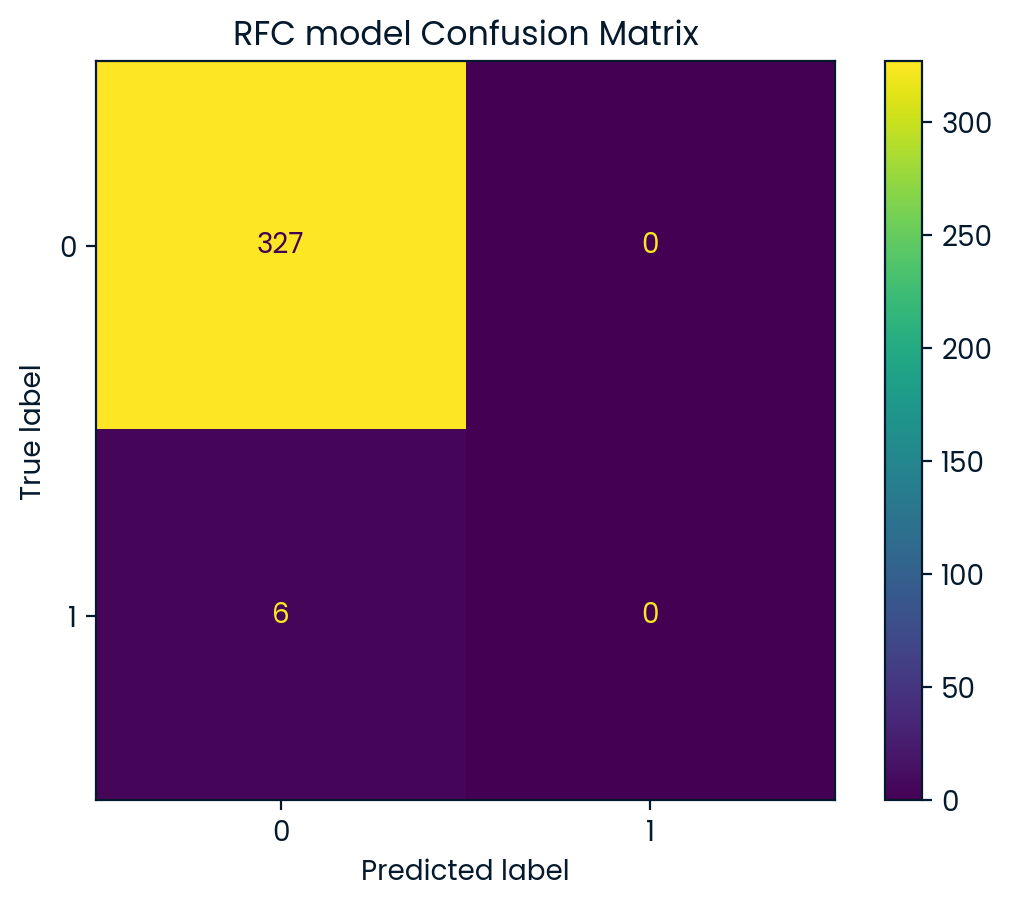

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       327
           1       0.00      0.00      0.00         6

    accuracy                           0.98       333
   macro avg       0.49      0.50      0.50       333
weighted avg       0.96      0.98      0.97       333



In [20]:
# connect the pipe to model
rfc_model= RandomForestClassifier(random_state=42,class_weight='balanced')

# instantiate model
rfc_model.fit(X_train_resampled,y_train_resampled)

# predict
rfc_y_pred = rfc_model.predict(X_test_preprocessed)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,rfc_y_pred)
plt.title('RFC model Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test,rfc_y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


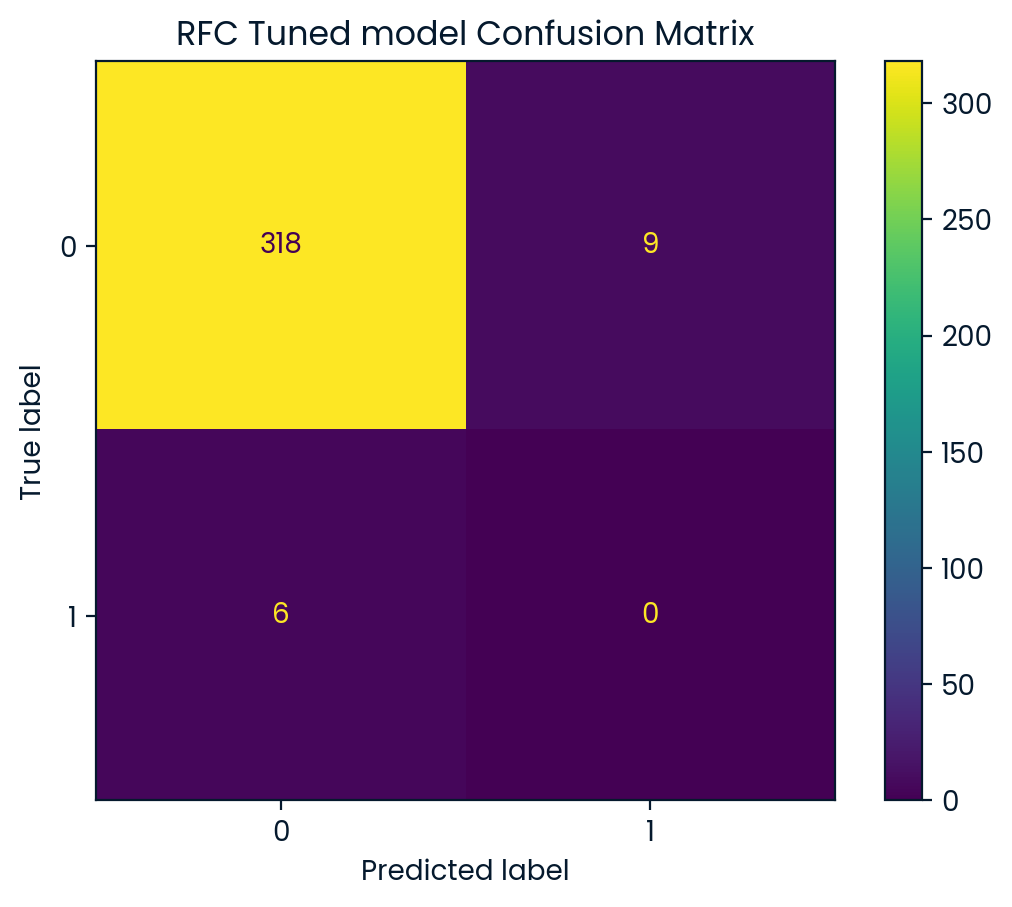

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       327
           1       0.00      0.00      0.00         6

    accuracy                           0.95       333
   macro avg       0.49      0.49      0.49       333
weighted avg       0.96      0.95      0.96       333



In [21]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# grid search for optimal parameter
rfc_model_tune = RandomizedSearchCV(estimator=rfc_model, param_distributions=param_grid, cv=5, scoring='recall', verbose=1, n_jobs=-1)

# instantiate model
rfc_model_tune.fit(X_train_resampled,y_train_resampled)

# predict
rfc_tune_y_pred = rfc_model_tune.predict(X_test_preprocessed)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,rfc_tune_y_pred)
plt.title('RFC Tuned model Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test,rfc_tune_y_pred))

## Easy Ensemble Classifier

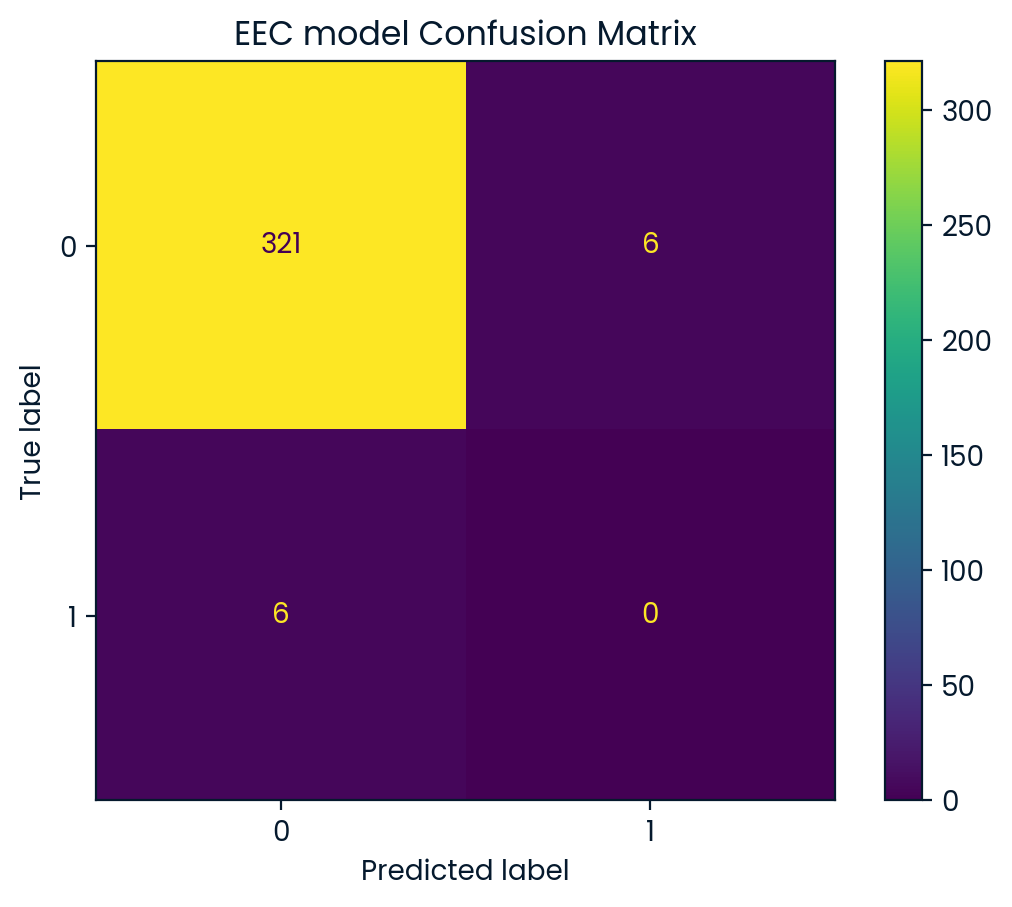

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       327
           1       0.00      0.00      0.00         6

    accuracy                           0.96       333
   macro avg       0.49      0.49      0.49       333
weighted avg       0.96      0.96      0.96       333

0.9828496042216359
0.963963963963964
CV train accuracy mean:0.9749522320653117 ,std dev:0.015642172135913006 


In [22]:
from imblearn.ensemble import EasyEnsembleClassifier

eec_model = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# instantiate model
eec_model.fit(X_train_resampled,y_train_resampled)

# predict
eec_y_pred = eec_model.predict(X_test_preprocessed)

# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,eec_y_pred)
plt.title('EEC model Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test,eec_y_pred))

print(eec_model.score(X_train_resampled,y_train_resampled))
print(eec_model.score(X_test_preprocessed,y_test))

# evaluate the cross validated performance on training data
cv_scores = cross_val_score(eec_model, X_train_resampled,y_train_resampled,cv=5, scoring='accuracy')

# print the results
print(f'CV train accuracy mean:{np.mean(cv_scores)} ,std dev:{np.std(cv_scores)} ')

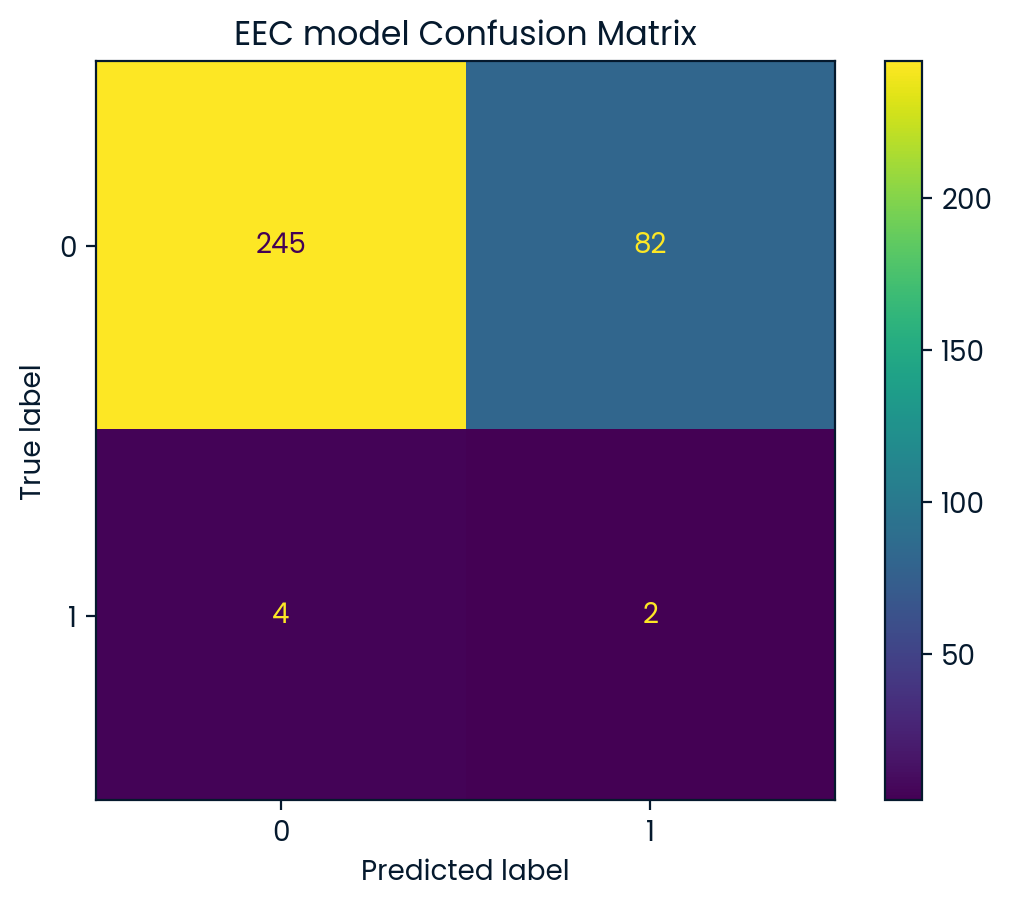

              precision    recall  f1-score   support

           0       0.98      0.75      0.85       327
           1       0.02      0.33      0.04         6

    accuracy                           0.74       333
   macro avg       0.50      0.54      0.45       333
weighted avg       0.97      0.74      0.84       333



In [23]:
 # Pipeline with same preprocessing 
pipe_ee = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', EasyEnsembleClassifier(random_state=42, n_estimators=10))
])

# Fit model
pipe_ee.fit(X_train, y_train)

# Predict
y_pred = pipe_ee.predict(X_test)


# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred )
plt.title('EEC model Confusion Matrix')
plt.show()

# Evaluation
print(classification_report(y_test, y_pred))



## BalancedRandomForestClassifier

[[306  21]
 [  5   1]]
              precision    recall  f1-score   support

           0     0.9839    0.9358    0.9592       327
           1     0.0455    0.1667    0.0714         6

    accuracy                         0.9219       333
   macro avg     0.5147    0.5512    0.5153       333
weighted avg     0.9670    0.9219    0.9433       333



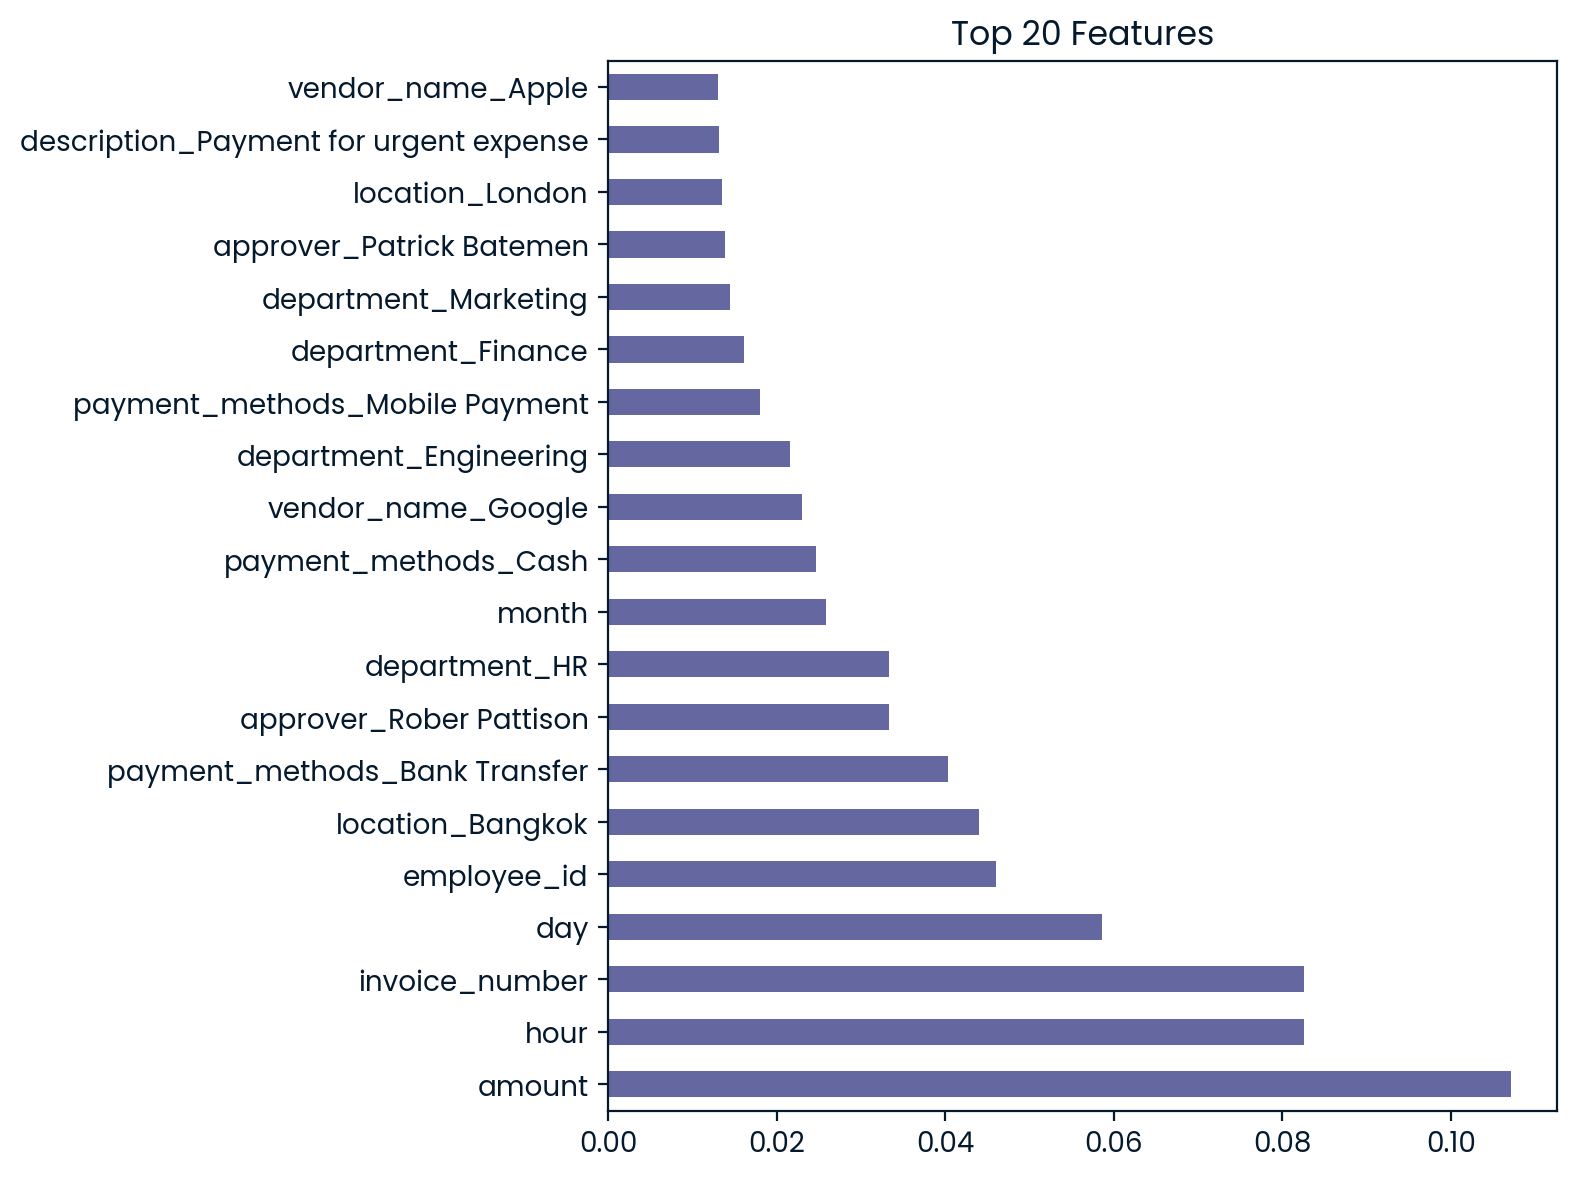

In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# build pipeline
pipe_brf = Pipeline([('preprocessor',preprocessor),('brf',BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight=None        
))])


pipe_brf.fit(X_train, y_train)

# Predict on test set
brf_y_pred = pipe_brf.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, brf_y_pred))
print(classification_report(y_test, brf_y_pred, digits=4))

# Get preprocessing step
preprocessor = pipe_brf.named_steps['preprocessor']

# Numeric and categorical transformers
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]

# Get encoded categorical feature names
ohe = preprocessor.transformers_[1][1].named_steps['encoder']
cat_encoded = ohe.get_feature_names_out(cat_features)

# Combine all final feature names
all_features = np.concatenate([num_features, cat_encoded])

# Get model from pipeline
model = pipe_brf.named_steps['brf']

# Create pandas Series of importances
importances = pd.Series(model.feature_importances_, index=all_features)

# Sort and plot
importances.nlargest(20).plot(kind='barh', figsize=(8, 6), title="Top 20 Features")
plt.tight_layout()
plt.show()



### Conclusion

Althought the project is stoped at using the Esay Assemble Classifier, what I noticed was using much more complex is of not getting better results but rather issues line in the data where it required more additional columns that would help model learn the subtle distinct difference that would allow to distinguish betweeen fraud and genuine.